## Project Goal
This notebook links Arabidopsis dry-weight phenotype data to genotype data and performs GWAS analysis step by step.

In [1]:
"""
In dit project haal ik een phenotype uit https://aragwas.1001genomes.org/#/
Ik link dit aan het genotype van arabidopsis thialiana (gevonden in https://aragwas.1001genomes.org/#/)
"""

'\nIn dit project haal ik een phenotype uit https://aragwas.1001genomes.org/#/\nIk link dit aan het genotype van arabidopsis thialiana (gevonden in https://aragwas.1001genomes.org/#/)\n'

## 1) Import Libraries and Load Phenotype Data
Load all required packages and read the phenotype table used in downstream analysis.

In [2]:
import h5py
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import statsmodels.api as sm
import limix
print(limix.__version__)



C:\Users\jandr\anaconda3\envs\limix_win\lib\site-packages\limix\_cli\_cli.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


3.0.4


In [3]:
DATA_PATH = "data"

pheno = pd.read_csv(f"{DATA_PATH}/plant_dry_weight.csv")
print(pheno.head())

  phenotype_name  accession_id accession_name accession_cs_number  \
0      rosetteDM            88            CYR             CS76790   
1      rosetteDM           108         LDV-18             CS77013   
2      rosetteDM           139         LDV-46             CS77014   
3      rosetteDM           159         MAR2-3             CS77070   
4      rosetteDM           265          PYL-6             CS77198   

   accession_longitude  accession_latitude accession_country  phenotype_value  \
0             0.683333             47.4000            France          238.430   
1            -4.066670             48.5167            France          290.955   
2            -4.066670             48.5167            France          292.970   
3             3.933330             47.3500            France          416.055   
4            -1.166670             44.6500            France          123.505   

   obs_unit_id  
0        17709  
1        17710  
2        17711  
3        17712  
4        1771

### Select Relevant Phenotype Columns
Keep only accession IDs and the phenotype value used for GWAS.

In [4]:
pheno = pheno[['accession_id', 'phenotype_value']]
print(pheno.head())

   accession_id  phenotype_value
0            88          238.430
1           108          290.955
2           139          292.970
3           159          416.055
4           265          123.505


## 2) Inspect Genotype HDF5 Structure
Open the genotype file and inspect available keys/datasets.

In [5]:
file_path = f"{DATA_PATH}/genotype.hdf5"

with h5py.File(file_path, "r") as f:
    print("Keys in file:")
    print(list(f.keys()))

Keys in file:
['accessions', 'positions', 'snps']


In [6]:
with h5py.File(file_path, "r") as f:
    for key in f.keys():
        print(key, f[key])

accessions <HDF5 dataset "accessions": shape (2029,), type "|S6">
positions <HDF5 dataset "positions": shape (10709466,), type "<i4">
snps <HDF5 dataset "snps": shape (10709466, 2029), type "|i1">


### Read Accessions, Positions, and SNP Subset
Load accession names, SNP positions, and a subset of SNPs for analysis.

In [6]:
with h5py.File("data/genotype.hdf5", "r") as f:
    accessions = [a.decode() for a in f["accessions"][:]]
    positions = f["positions"][:]
    
    # selecteer bijvoorbeeld eerste 50,000 SNPs
    snp_subset = f["snps"][:50000, :]

### Build Genotype Matrix
Convert SNP array to a sample-by-SNP DataFrame.

In [7]:
geno = pd.DataFrame(
    snp_subset.T, 
    index=accessions
)

In [8]:
print(geno.head())

     0      1      2      3      4      5      6      7      8      9      \
88       0      0      0      0      0      0      0      1      0      0   
108      0      0      0      0      0      0      0      1      0      0   
139      0      0      0      0      0      0      0      1      0      0   
159      0      0      0      0      0      0      0      0      0      0   
265      0      0      0      0      0      0      0      0      0      0   

     ...  49990  49991  49992  49993  49994  49995  49996  49997  49998  49999  
88   ...      0      0      0      0      0      0      0      0      0      0  
108  ...      0      0      0      0      0      0      0      0      0      0  
139  ...      0      0      0      0      0      0      0      0      0      0  
159  ...      0      0      0      0      0      0      0      0      0      0  
265  ...      0      0      0      0      0      0      0      0      0      0  

[5 rows x 50000 columns]


## 3) Clean and Harmonize Sample IDs
Set accession IDs as indices, fix datatypes, and remove duplicates.

In [9]:
# Zet phenotype index op accession_name
pheno = pheno.set_index("accession_id")
print(pheno.index[:5])
print(geno.index[:5])
pheno.index.duplicated().sum() #twee duplicates in pheno!


pheno.index = pheno.index.astype(int)
geno.index = geno.index.astype(int)
pheno = pheno[~pheno.index.duplicated(keep="first")]  #removed duplicates
print(pheno.index[:5])
print(geno.index[:5])


Int64Index([88, 108, 139, 159, 265], dtype='int64', name='accession_id')
Index(['88', '108', '139', '159', '265'], dtype='object')
Int64Index([88, 108, 139, 159, 265], dtype='int64', name='accession_id')
Int64Index([88, 108, 139, 159, 265], dtype='int64')


### Keep Only Overlapping Accessions
Restrict phenotype and genotype tables to shared accessions in identical order.

In [10]:
# Neem alleen overlappende accessions
common = pheno.index.intersection(geno.index)
print("Aantal overlap:", len(common))

# Sorteer de IDs zodat beide datasets exact dezelfde volgorde hebben
common = common.sort_values()

# Subset beide datasets
pheno = pheno.loc[common]
geno = geno.loc[common]

print("common:", common.shape)
print("pheno:", pheno.shape)
print("geno:", geno.shape)

Aantal overlap: 420
common: (420,)
pheno: (420, 1)
geno: (420, 50000)


In [11]:
print(pheno.index[:10])
print(geno.index[:10])

Int64Index([88, 108, 139, 159, 265, 410, 428, 430, 763, 765], dtype='int64')
Int64Index([88, 108, 139, 159, 265, 410, 428, 430, 763, 765], dtype='int64')


In [12]:
"""
Interpretatie:

Je phenotype file bevat 422 accessions

Je genotype subset bevat 2029 accessions totaal, maar

Slechts 420 komen in beide voor (zijn accessories met zowel een phenotype en een genotype)
"""

'\nInterpretatie:\n\nJe phenotype file bevat 422 accessions\n\nJe genotype subset bevat 2029 accessions totaal, maar\n\nSlechts 420 komen in beide voor (zijn accessories met zowel een phenotype en een genotype)\n\nDus:\n\nðŸ‘‰ 2 phenotype accessions hebben gÃ©Ã©n genotype\nðŸ‘‰ 1609 genotype accessions hebben gÃ©Ã©n phenotype\n\nDit is volledig normaal bij Arabidopsis datasets.\n'

## 4) SNP Quality Control
Handle missing values and remove SNPs with high missingness.

In [13]:
# Vul eventueel missing data met NaN
geno = geno.replace(-1, np.nan)  # afhankelijk van je HDF5 encoding

# Missingness filter: verwijder SNPs met >10% missing
geno = geno.loc[:, geno.isna().mean() < 0.1]

### Minor Allele Frequency (MAF) Filtering
Keep informative SNPs by excluding rare variants below the MAF threshold.

In [14]:
# MAF filter: verwijder SNPs met MAF < 0.05

#geno.mean = gemiddelde genotypische waarde per SNP -> delen door 2 geeft frequentie van het alternatieve allel
allele_freq = geno.mean(axis=0) / 2  # 0,1,2 encoding â†’ freq alt allele

#allele_freq is frequentie van alternatieve allel, 1-allele_freq is frequentie van referentie allel
#minimum van beide is Minor Allele Frequency (MAF)
maf = np.minimum(allele_freq, 1 - allele_freq)

#filter op MAF â‰¥ 0.05
geno = geno.loc[:, maf > 0.05]

In [15]:
print("Aantal SNPs na filtering:", geno.shape[1])

Aantal SNPs na filtering: 5568


## 5) PCA for Population Structure
Compute principal components from genotype data and append PCs to phenotype data.

     7      43     63     79     85     90     91     121    131    140    \
88       1      0      0      1      1      0      1      0      1      0   
108      1      0      0      0      0      0      1      0      0      0   
139      1      0      0      0      0      0      1      0      0      0   
159      0      0      0      0      0      0      0      0      0      0   
265      0      0      1      0      0      1      1      1      1      1   

     ...  49915  49932  49936  49973  49974  49975  49976  49977  49982  49995  
88   ...      0      0      1      1      1      1      1      1      1      0  
108  ...      0      1      1      1      1      1      1      1      1      0  
139  ...      0      0      1      1      1      1      1      1      1      0  
159  ...      0      0      1      1      1      1      1      1      1      0  
265  ...      0      0      1      1      1      1      1      1      1      0  

[5 rows x 5568 columns]
          PC1        PC2  

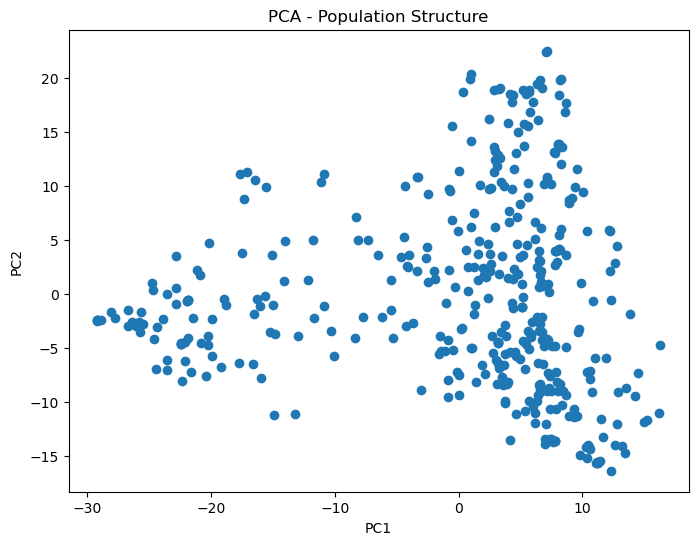

In [16]:
# Vul missing values voor PCA
geno_filled = geno.fillna(geno.mean())
print(geno_filled.head())

# PCA uitvoeren
pca = PCA(n_components=10) #5 PC's although we only plot first 10 PCs
pcs = pca.fit_transform(geno_filled)

# DataFrame met PC scores
pcs_df = pd.DataFrame(pcs, index=geno.index, columns=[f'PC{i+1}' for i in range(pcs.shape[1])])
print(pcs_df.head())

# Voeg PC1 tot PC10 toe aan phenotype dataframe
pheno = pheno.join(pcs_df)

# Plot PCA (PC1 vs PC2)
plt.figure(figsize=(8,6))
plt.scatter(pheno['PC1'], pheno['PC2'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - Population Structure')
plt.show()

In [17]:
print(pheno.head())

     phenotype_value       PC1        PC2       PC3       PC4       PC5  \
88           238.430  8.101170  18.466258 -1.508176 -2.562797  2.679219   
108          290.955  7.754895  13.042208 -1.493693 -0.620488  0.603689   
139          292.970  7.679218  13.189680 -1.522375 -0.540439  0.452069   
159          416.055  4.800679  14.967993  0.733306  4.812871  1.616505   
265          123.505  6.298438  -2.132022  9.286296 -0.157887 -0.352888   

          PC6       PC7       PC8       PC9      PC10  
88  -5.679700  5.395365  3.220903  5.042636  3.655531  
108 -8.240293 -2.996329 -2.328904  0.374305 -9.063706  
139 -8.247600 -2.942929 -2.345169  0.354229 -8.944572  
159 -3.598723 -3.087158  1.687367  3.145685  0.622887  
265 -2.163367 -3.529186  3.890508 -5.269069 -0.037065  


### Evaluate PCA Explained Variance
Check variance captured by each PC and cumulative trend.

PC1 explains 12.57% of total variance
PC2 explains 7.92% of total variance
PC3 explains 5.40% of total variance
PC4 explains 4.26% of total variance
PC5 explains 3.75% of total variance
PC6 explains 3.01% of total variance
PC7 explains 2.62% of total variance
PC8 explains 2.41% of total variance
PC9 explains 2.23% of total variance
PC10 explains 2.19% of total variance


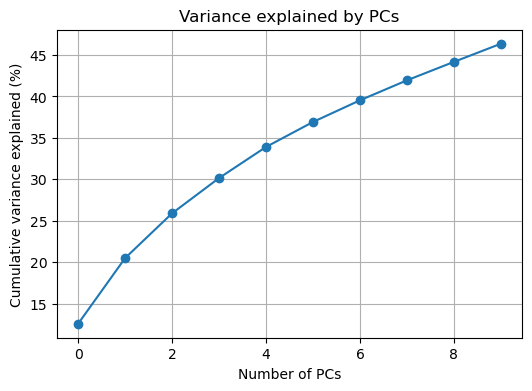

In [18]:
#Check variance explained by each PC
explained_var = pca.explained_variance_ratio_
for i, var in enumerate(explained_var):
    print(f"PC{i+1} explains {var*100:.2f}% of total variance")

# Optioneel: cumulative variance plot
plt.figure(figsize=(6,4))
plt.plot(np.cumsum(explained_var)*100, marker='o')
plt.xlabel('Number of PCs')
plt.ylabel('Cumulative variance explained (%)')
plt.title('Variance explained by PCs')
plt.grid(True)
plt.show()

In [19]:
"""
is there not a lot of variation lost by doing PCA?
You have tens of thousands of SNPs (~50k in your subset). In genomics, itâ€™s common for the first 2â€“5 PCs to explain 20â€“40% of variance. 
GWAS pipelines usually donâ€™t need to capture 100% of variance.
Goal of PCs in GWAS: not to explain all variance, but to capture population structure / ancestry to avoid false positives.
The remaining ~65% of SNP variance is mostly random variation, technical noise, or very subtle structure, which GWAS will deal with via residuals.
"""

'\nis there not a lot of variation lost by doing PCA?\nYou have tens of thousands of SNPs (~50k in your subset). In genomics, itâ€™s common for the first 2â€“5 PCs to explain 20â€“40% of variance. \nGWAS pipelines usually donâ€™t need to capture 100% of variance.\nGoal of PCs in GWAS: not to explain all variance, but to capture population structure / ancestry to avoid false positives.\nThe remaining ~65% of SNP variance is mostly random variation, technical noise, or very subtle structure, which GWAS will deal with via residuals.\n'

In [20]:
print(geno.head())
print(geno.shape)
print(pheno.shape)

     7      43     63     79     85     90     91     121    131    140    \
88       1      0      0      1      1      0      1      0      1      0   
108      1      0      0      0      0      0      1      0      0      0   
139      1      0      0      0      0      0      1      0      0      0   
159      0      0      0      0      0      0      0      0      0      0   
265      0      0      1      0      0      1      1      1      1      1   

     ...  49915  49932  49936  49973  49974  49975  49976  49977  49982  49995  
88   ...      0      0      1      1      1      1      1      1      1      0  
108  ...      0      1      1      1      1      1      1      1      1      0  
139  ...      0      0      1      1      1      1      1      1      1      0  
159  ...      0      0      1      1      1      1      1      1      1      0  
265  ...      0      0      1      1      1      1      1      1      1      0  

[5 rows x 5568 columns]
(420, 5568)
(420, 11)


## 6) Initial GWAS Using OLS
Run SNP-wise linear models with phenotype as response and PCs as covariates.

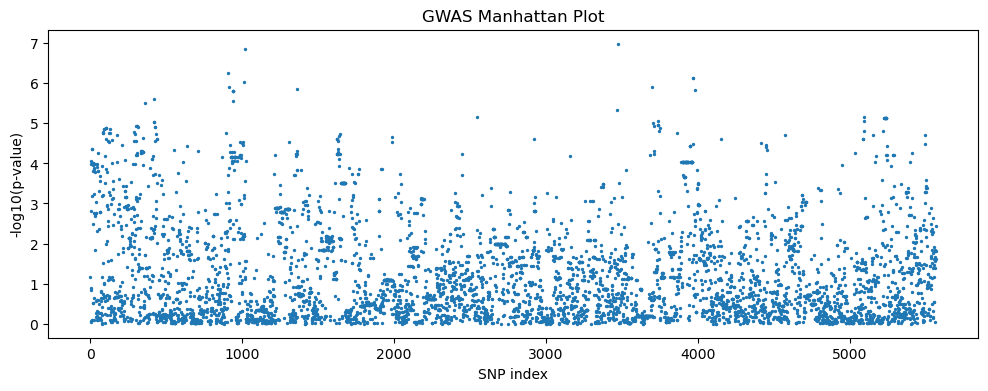

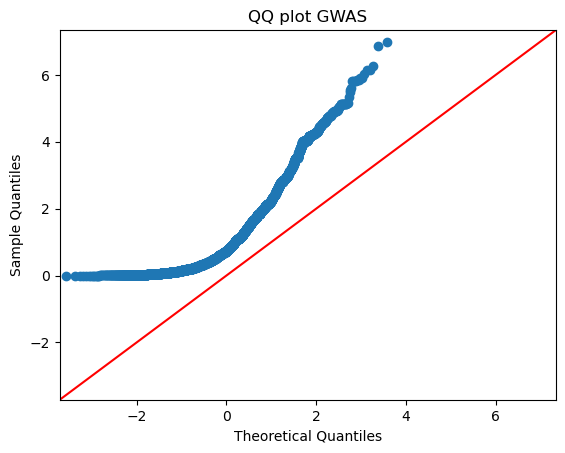

In [21]:
phenotype_col = 'phenotype_value'
p_values = []

for snp in geno.columns:
    X = pheno[['PC1','PC2']].copy()
    X[snp] = geno[snp]
    X = sm.add_constant(X)
    y = pheno[phenotype_col]
    
    try:
        model = sm.OLS(y, X).fit()
        p_values.append(model.pvalues[snp])
    except:
        p_values.append(np.nan)

# Manhattan plot
plt.figure(figsize=(12,4))
plt.scatter(range(len(p_values)), -np.log10(p_values), s=2)
plt.xlabel('SNP index')
plt.ylabel('-log10(p-value)')
plt.title('GWAS Manhattan Plot')
plt.show()

# QQ plot
from statsmodels.graphics.gofplots import qqplot
qqplot(-np.log10([p for p in p_values if not np.isnan(p)]), line='45')
plt.title('QQ plot GWAS')
plt.show()

In [22]:
"""
clearly inflated because alll points are above the diagonal 
"""

'\nclearly inflated because alll points are above the diagonal \n'

### Quantify Genomic Inflation
Calculate lambda GC to assess potential p-value inflation.

In [23]:
from scipy.stats import chi2
import numpy as np

# Remove nan p-values
pvals_clean = np.array(p_values)
pvals_clean = pvals_clean[~np.isnan(pvals_clean)]

# Convert p-values to chi-square statistics
chi2_stats = chi2.ppf(1 - pvals_clean, df=1)

# Calculate lambda
lambda_gc = np.median(chi2_stats) / 0.456

print("Genomic inflation factor (lambda):", lambda_gc)

Genomic inflation factor (lambda): 3.825640604339765


In [24]:
"""
lambda is 3.96 -> way too high -> add more PCs
"""

'\nlambda is 3.96 -> way too high -> add more PCs\n'

## 7) Re-run OLS GWAS With More PCs
Increase the number of PC covariates to reduce structure-related inflation.

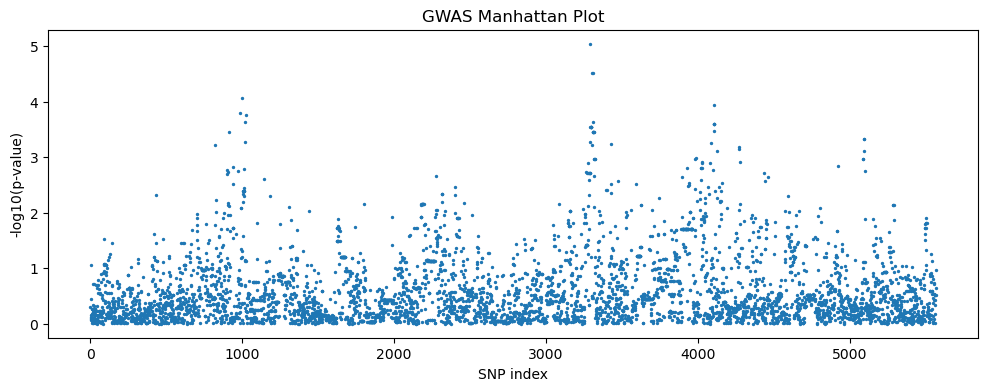

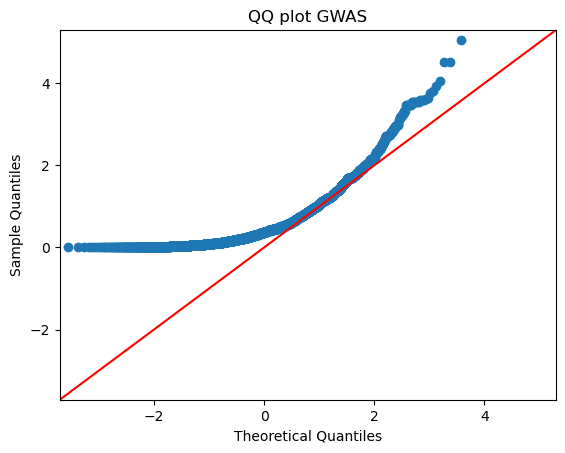

In [25]:
phenotype_col = 'phenotype_value'
p_values = []

for snp in geno.columns:
    X = pheno[['PC1','PC2', 'PC3','PC4', 'PC5']].copy()
    X[snp] = geno[snp]
    X = sm.add_constant(X)
    y = pheno[phenotype_col]
    
    try:
        model = sm.OLS(y, X).fit()
        p_values.append(model.pvalues[snp])
    except:
        p_values.append(np.nan)

# Manhattan plot
plt.figure(figsize=(12,4))
plt.scatter(range(len(p_values)), -np.log10(p_values), s=2)
plt.xlabel('SNP index')
plt.ylabel('-log10(p-value)')
plt.title('GWAS Manhattan Plot')
plt.show()

# QQ plot
from statsmodels.graphics.gofplots import qqplot
qqplot(-np.log10([p for p in p_values if not np.isnan(p)]), line='45')
plt.title('QQ plot GWAS')
plt.show()

### OLS GWAS With 10 PCs
Repeat association testing with a larger covariate set.

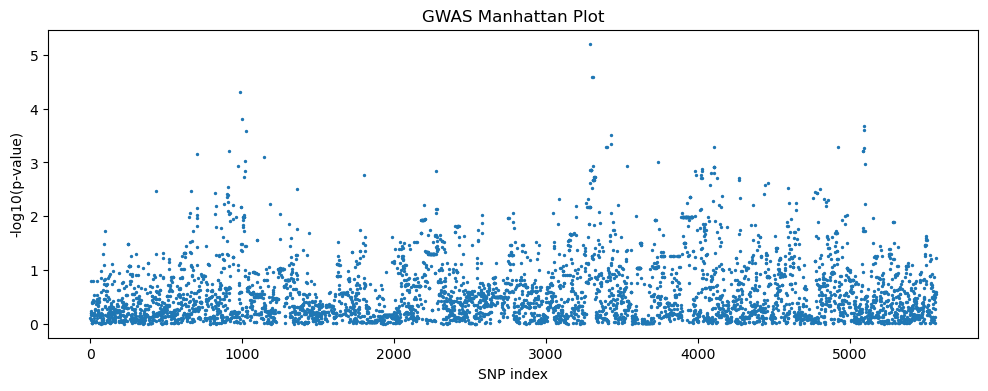

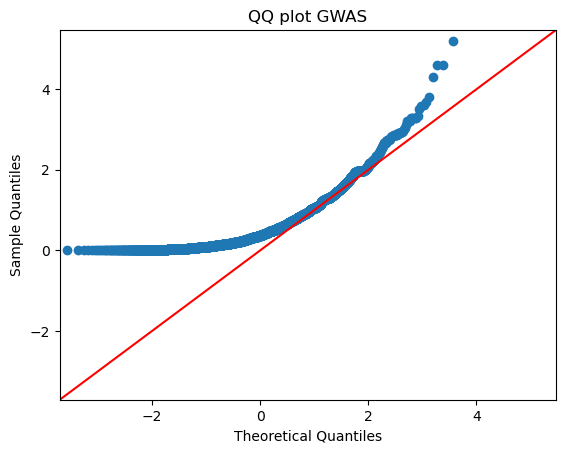

In [26]:
phenotype_col = 'phenotype_value'
p_values = []

for snp in geno.columns:
    X = pheno[['PC1','PC2', 'PC3','PC4', 'PC5', 'PC6','PC7', 'PC8','PC9', 'PC10']].copy()
    X[snp] = geno[snp]
    X = sm.add_constant(X)
    y = pheno[phenotype_col]
    
    try:
        model = sm.OLS(y, X).fit()
        p_values.append(model.pvalues[snp])
    except:
        p_values.append(np.nan)

# Manhattan plot
plt.figure(figsize=(12,4))
plt.scatter(range(len(p_values)), -np.log10(p_values), s=2)
plt.xlabel('SNP index')
plt.ylabel('-log10(p-value)')
plt.title('GWAS Manhattan Plot')
plt.show()

# QQ plot
from statsmodels.graphics.gofplots import qqplot
qqplot(-np.log10([p for p in p_values if not np.isnan(p)]), line='45')
plt.title('QQ plot GWAS')
plt.show()

In [28]:
phenotype_col = 'phenotype_value'
p_values = []


## 8) Mixed Model Preparation (LIMIX)
Prepare phenotype, genotype, kinship, and covariates for mixed-model GWAS.

In [30]:
#let's use the limix library for Mixed Linear Model

#prepare the data
# phenotype vector
y = pheno[phenotype_col].values


# genotype matrix
G = geno.values

In [31]:
print(y[0:5,])
print(G[0:5, 0:5])

[238.43  290.955 292.97  416.055 123.505]
[[1 0 0 1 1]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [0 0 0 0 0]
 [0 0 1 0 0]]


In [32]:
from limix.stats import linear_kinship

K = linear_kinship(G)

Kinship: 100%|███████████████████████████████████████████████████████████████████████████████████| 101/101 [00:00<00:00, 576.73it/s]


In [33]:
y = y.reshape(-1,1)

In [34]:
# covariates (PCs)
PCs = pheno[[f'PC{i}' for i in range(1,6)]].values
covs = np.column_stack([
    np.ones(len(y)),  # intercept
    PCs
])

print(covs[0:5, 0:5])

[[ 1.          8.10116956 18.46625803 -1.50817637 -2.56279661]
 [ 1.          7.75489537 13.04220838 -1.49369275 -0.62048822]
 [ 1.          7.67921792 13.18968016 -1.52237452 -0.54043851]
 [ 1.          4.80067867 14.96799332  0.73330611  4.81287076]
 [ 1.          6.29843822 -2.13202183  9.28629574 -0.15788664]]


In [35]:
print(G.shape)      # SNP matrix (samples Ã— SNPs)
print(y.shape)      # phenotype (samples Ã— 1)
print(K.shape)      # kinship (samples Ã— samples)
print(covs.shape)   # covariates (samples Ã— covariates)

(420, 5568)
(420, 1)
(420, 420)
(420, 6)


In [36]:
print(pd.__version__)

1.5.3


### LIMIX Compatibility Patch and Scan
Apply compatibility fix (if needed), then run mixed-model association scan.

In [37]:
import sys
import types
import pandas as pd

# create a fake module 'pandas.core.index'
mod = types.SimpleNamespace()

# use the public InvalidIndexError from pandas.errors
from pandas.errors import InvalidIndexError
mod.InvalidIndexError = InvalidIndexError

# insert it into sys.modules so Python uses it whenever something does
# 'from pandas.core.index import InvalidIndexError'
sys.modules['pandas.core.index'] = mod

# Now import LIMIX
from limix.qtl import scan


### Extract LIMIX P-values
Collect p-values from LIMIX GWAS output for interpretation and plotting.

In [38]:
result = scan(
    G=G,
    Y=y,
    K=K,
    M=covs
)

pvals = result.stats["pv20"]

================================= QTL analysis starts ==================================

Normalising input... 
done (1.89 seconds).

Input
-----

Likelihood       : normal
Traits (1)       : [0]
Covariates (6)   : [0, 1, 2, ..., 5]
Variants 5568    : [0, 1, 2, ..., 5567]
N. of candidates : 5568
Kinship          : present



LMM: 28it [00:00, 172.53it/s]
Results: 100%|███████████████████████████████████████████████████████████████████████████████| 5568/5568 [00:00<00:00, 16081.76it/s]



Hypothesis 0
------------

𝐲 ~ 𝓝(𝙼𝜶, 53711.622⋅𝙺 + 263539.184⋅𝙸)

M     = ['0' '1' '2' '3' '4' '5']
𝜶     = [635.0740119    6.7278015  -13.24851006  22.41137886  -1.28368507    3.53327667]
se(𝜶) = [25.04943605  7.34936615  7.70633548  8.29831298  8.38062266  8.27402927]
lml   = -3243.3995044542667

Hypothesis 2
------------

𝐲 ~ 𝓝(𝙼𝜶 + G𝛃, s(53711.622⋅𝙺 + 263539.184⋅𝙸))

          lml       cov. effsizes   cand. effsizes
--------------------------------------------------
mean   -3.243e+03       1.083e+02        6.342e+00
std     7.817e-01       2.352e+02        1.043e+02
min    -3.243e+03      -2.440e+01       -4.792e+02
25%    -3.243e+03      -1.284e+00       -6.117e+01
50%    -3.243e+03       5.160e+00       -1.751e+00
75%    -3.243e+03       2.242e+01        6.522e+01
max    -3.235e+03       1.106e+03        3.892e+02

Likelihood-ratio test p-values
------------------------------

       𝓗₀ vs 𝓗₂ 
----------------
mean   4.994e-01
std    2.975e-01
min    4.723e-05
25%    2.373e-01


========================== QTL analysis ends in 8.24 seconds ===========================